In [1]:
import os
import json
import pandas as pd
import numpy as np
from shapely.geometry import Point
from pyproj import Transformer
from shapely.ops import unary_union
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer
import pandas as pd
import numpy as np
import re

In [2]:


def extract_img_index(name):
    # Extract numeric index from img_name like "192_168_1_11_im_4.jpg" -> 4
    match = re.search(r'pose_(\d+)\.jpg', name)
    return int(match.group(1)) if match else None

def circular_mean(a1, a2):
    # Compute the mean of two angles in degrees with wraparound
    a1_rad, a2_rad = np.radians([a1, a2])
    x = np.cos(a1_rad) + np.cos(a2_rad)
    y = np.sin(a1_rad) + np.sin(a2_rad)
    return np.degrees(np.arctan2(y, x)) % 360

# === Load CSV ===
csv_path = "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/df_ref_images_192_168_1_11.csv"
df = pd.read_csv(csv_path)

# === Extract and sort image indices ===
df["img_index"] = df["img_name"].apply(extract_img_index)
df = df.sort_values("img_index").reset_index(drop=True)

# === Find missing index ===
all_indices = df["img_index"].tolist()
expected_indices = list(range(min(all_indices), max(all_indices) + 1))
missing = list(set(expected_indices) - set(all_indices))

if len(missing) >0:
   
    missing_idx = missing[0]

    print(f"📷 Missing image index: {missing_idx}")

    # === Find insert position ===
    insert_pos = next(i for i, idx in enumerate(df["img_index"]) if idx > missing_idx)

    # === Estimate values ===
    az1 = df.iloc[insert_pos - 1]["centre"]
    az2 = df.iloc[insert_pos]["centre"]
    centre = round(circular_mean(az1, az2), 2)

    real_az1 = df.iloc[insert_pos - 1]["real_azimuth"]
    real_az2 = df.iloc[insert_pos]["real_azimuth"]
    real_az = round(circular_mean(real_az1, real_az2), 2)

    # === Construct new row ===
    new_row = {
        "img_name": f"pose_{missing_idx}.jpg",
        "dem_image": f"{int(real_az):03}.jpg",  # e.g. 145.0 → 145.jpg
        "dx": np.nan,  # Unknown
        "real_azimuth": real_az,
        "centre": centre,
        "img_index": missing_idx
    }

    # === Insert and sort again ===
    df = pd.concat([
        df.iloc[:insert_pos],
        pd.DataFrame([new_row]),
        df.iloc[insert_pos:]
    ], ignore_index=True).drop(columns="img_index")

    # === Save updated CSV ===
    df.to_csv(csv_path, index=False)
    print(f"✅ Filled missing row for im_{missing_idx}. Saved to CSV.")


/var/folders/wp/zz11dqlj2xg4yt1xmynhrc8c0000gn/T/ipykernel_99572/371901481.py:97: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gdf_cones.plot(ax=ax, color=colors[label], alpha=0.3, label=f"{label} FOV")
/var/folders/wp/zz11dqlj2xg4yt1xmynhrc8c0000gn/T/ipykernel_99572/371901481.py:98: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gdf_rays.plot(ax=ax, color=colors[label], linewidth=1.2, label=f"{label} rays")
/var/folders/wp/zz11dqlj2xg4yt1xmynhrc8c0000gn/T/ipykernel_99572/371901481.py:97: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gdf_cones.plot(ax=ax, color=colors[label], alpha=0.3, label=f"{label} FOV")
/var/folders/wp/zz11dqlj2xg4yt1xmynhrc8c0000gn/T/ipykernel_99572/371901481.py:98: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gdf_rays.plot(ax=ax, color=colors[label], linewidth=1.2, label=f

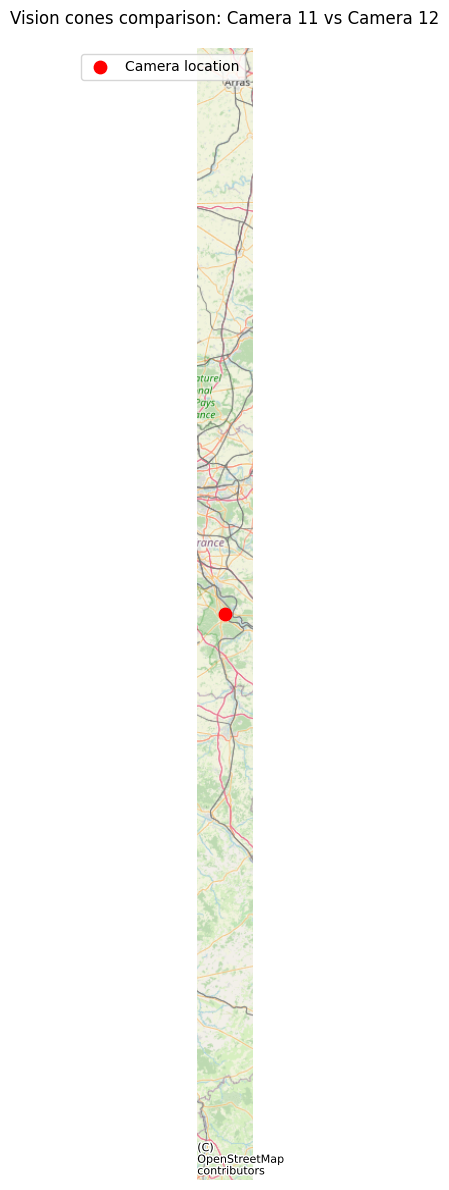

In [4]:
import json
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point, LineString
from pyproj import Transformer

# === Helper functions ===

def build_fov_geometries(cam_loc, azimuth_deg, fov_deg=54.2, view_distance=5000):
    cam_x, cam_y, _, _ = cam_loc
    cam_point = Point(cam_x, cam_y)

    half_fov = fov_deg / 2
    angles_rad = np.radians([azimuth_deg - half_fov, azimuth_deg + half_fov])

    # FOV cone
    cone_pts = [
        cam_point,
        Point(cam_x + view_distance * np.sin(angles_rad[0]),
              cam_y + view_distance * np.cos(angles_rad[0])),
        Point(cam_x + view_distance * np.sin(angles_rad[1]),
              cam_y + view_distance * np.cos(angles_rad[1]))
    ]
    cone = cone_pts[0].buffer(1).union(cone_pts[1]).union(cone_pts[2]).convex_hull
    ray = LineString([cam_point, (
        cam_x + view_distance * np.sin(np.radians(azimuth_deg)),
        cam_y + view_distance * np.cos(np.radians(azimuth_deg))
    )])

    return cone, ray

# === Camera metadata ===
name = "augas"
config_path = f"site_data/{name}/camera_config.json"
with open(config_path, "r") as f:
    cam_meta = json.load(f)

transformer = Transformer.from_crs("EPSG:4326", "EPSG:2154", always_xy=True)
cam_x, cam_y = transformer.transform(cam_meta["lon"], cam_meta["lat"])
cam_loc = (cam_x, cam_y, 0, "EPSG:2154")
gdf_cam = gpd.GeoSeries([Point(cam_x, cam_y)], crs="EPSG:2154").to_crs(epsg=3857)

# === Load both CSVs ===
csv_paths = {
    "Camera 11": f"/Users/mateo/pyronear/vision/smoke-localization/site_data/{name}/df_ref_images_192_168_1_11.csv",
    "Camera 12": f"/Users/mateo/pyronear/vision/smoke-localization/site_data/{name}/df_ref_images_192_168_1_12.csv"
}
colors = {
    "Camera 11": "orange",
    "Camera 12": "cyan"
}

# Optional pose filtering
pose_filters = {
    "Camera 11": None,  # inclusive: poses 2, 3, 4, 5
    "Camera 12": None,                # None means plot all poses
}

fig, ax = plt.subplots(figsize=(12, 12))
for label, path in csv_paths.items():
    df = pd.read_csv(path)
    cones = []
    rays = []
    annotations = []

    # cam_id = os.path.basename(path).split('_')[-1].split('.')[0]

    for _, row in df.iterrows():
        match = re.search(r'pose_(\d+)\.jpg', row["img_name"])
        if not match:
            continue
        pose_id = int(match.group(1))

        # Apply pose filtering
        allowed_poses = pose_filters.get(label)
        if allowed_poses is not None and pose_id not in allowed_poses:
            continue

        cone, ray = build_fov_geometries(cam_loc, row["centre"])
        cones.append(cone)
        rays.append(ray)

        # Get label position (end of the ray)
        ray_end_x, ray_end_y = ray.coords[-1]
        annotations.append({
            "x": ray_end_x,
            "y": ray_end_y,
            "label": f"{row['centre']:.1f}°\npose {pose_id}"
        })

    gdf_cones = gpd.GeoSeries(cones, crs="EPSG:2154").to_crs(epsg=3857)
    gdf_rays = gpd.GeoSeries(rays, crs="EPSG:2154").to_crs(epsg=3857)

    gdf_cones.plot(ax=ax, color=colors[label], alpha=0.3, label=f"{label} FOV")
    gdf_rays.plot(ax=ax, color=colors[label], linewidth=1.2, label=f"{label} rays")

    # Plot azimuth annotations
    transformer = Transformer.from_crs("EPSG:2154", "EPSG:3857", always_xy=True)
    for ann in annotations:
        x_web, y_web = transformer.transform(ann["x"], ann["y"])
        ax.annotate(
            ann["label"],
            (x_web, y_web),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            color="black",
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3', alpha=0.8)
        )


# === Camera position ===
gdf_cam.plot(ax=ax, color="red", markersize=80, label="Camera location")

# === Final touches ===
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Vision cones comparison: Camera 11 vs Camera 12")
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()


In [18]:
for label, path in csv_paths.items():
    df = pd.read_csv(path)
    print(path)
    l = list(df["centre"].astype('int'))
    print(f":{l},")

/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/df_ref_images_192_168_1_11.csv
:[52, 100, 147, 194],
/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/df_ref_images_192_168_1_12.csv
:[246, 291, 340, 25],
